# Notebook 5: Statistical Analysis and Feature Validation

## Introduction

The previous notebooks focused on data collection, preprocessing, exploratory data analysis, and feature engineering. While exploratory analysis identified potential relationships among air quality, biomass burning, and meteorological variables, these observations require statistical validation before developing predictive models.

This notebook evaluates the statistical properties of the engineered dataset by examining descriptive statistics, testing variable distributions, assessing linear relationships, and identifying significant predictors of next-day Air Quality Index (AQI). The findings provide quantitative evidence supporting feature selection and establish a strong statistical foundation for the subsequent machine learning models.

The statistical analysis consists of the following stages:

- Dataset Loading
- Descriptive Statistics
- Normality Assessment
- Correlation Significance Analysis
- Multiple Linear Regression
- Multicollinearity Assessment
- Statistical Findings

# 1. Load Feature-Engineered Dataset

The feature-engineered dataset created in the previous notebook is loaded for statistical analysis. Before performing any statistical tests, the dataset structure and data types are verified to ensure that all engineered features have been correctly generated.

In [1]:
import pandas as pd
import numpy as np

import scipy.stats as stats

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

feature_df = pd.read_csv("feature_engineered_dataset.csv")

feature_df["Date"] = pd.to_datetime(feature_df["Date"])

In [2]:
feature_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1847 entries, 0 to 1846
Data columns (total 28 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                1847 non-null   datetime64[ns]
 1   AQI                 1847 non-null   float64       
 2   AQI_Bucket          1847 non-null   object        
 3   PM2.5               1847 non-null   float64       
 4   Fire_Count          1847 non-null   int64         
 5   Total_FRP           1847 non-null   float64       
 6   Mean_FRP            1847 non-null   float64       
 7   Max_FRP             1847 non-null   float64       
 8   Mean_U10            1847 non-null   float64       
 9   Mean_V10            1847 non-null   float64       
 10  Mean_Wind_Speed     1847 non-null   float64       
 11  Max_Wind_Speed      1847 non-null   float64       
 12  Avg_Temperature_C   1847 non-null   float64       
 13  Avg_DewPoint_C      1847 non-null   float64     

# 2. Descriptive Statistics

Descriptive statistics provide a quantitative summary of the engineered variables by reporting measures of central tendency and dispersion. These statistics help identify unusual values, verify feature ranges, and provide an overview of the modelling dataset before formal statistical testing.

In [3]:
statistical_columns = [

    "AQI_next_day",

    "AQI_lag1",
    "AQI_lag2",
    "AQI_lag3",

    "AQI_rolling_mean_3",
    "AQI_rolling_std_3",

    "Fire_Count",
    "Fire_Count_lag1",
    "Fire_Count_lag2",

    "Total_FRP",
    "Total_FRP_lag1",
    "Total_FRP_lag2",

    "Mean_Wind_Speed",
    "Max_Wind_Speed",

    "Avg_Temperature_C",
    "Relative_Humidity"

]

feature_df[statistical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
AQI_next_day,1847.0,267.532756,117.839585,30.000000,172.500000,268.000000,352.000000,716.000000
AQI_lag1,1847.0,267.666486,117.763293,30.000000,173.000000,268.000000,352.000000,716.000000
AQI_lag2,1847.0,267.806172,117.831234,30.000000,173.000000,268.000000,352.000000,716.000000
AQI_lag3,1847.0,268.001083,117.871108,30.000000,173.000000,269.000000,352.000000,716.000000
AQI_rolling_mean_3,1847.0,267.824580,112.194498,34.000000,178.833333,269.333333,349.833333,665.000000
AQI_rolling_std_3,1847.0,35.254626,26.420704,0.000000,16.227519,28.307832,46.622458,184.971169
Fire_Count,1847.0,304.472658,759.684275,1.000000,11.000000,40.000000,133.000000,8659.000000
Fire_Count_lag1,1847.0,304.461830,759.688417,1.000000,11.000000,40.000000,133.000000,8659.000000
Fire_Count_lag2,1847.0,304.445046,759.694473,1.000000,11.000000,40.000000,133.000000,8659.000000
Total_FRP,1847.0,1967.098858,5353.550491,0.440000,37.060000,158.380000,675.675000,61479.850000


## Findings

The descriptive statistics provide an overview of the engineered modelling dataset and confirm that the variables are suitable for subsequent statistical analysis.

The target variable (AQI_next_day) has a mean value of approximately 267.53 with a standard deviation of 117.84, indicating substantial day-to-day variation in air quality. The similarity between the descriptive statistics of AQI_next_day and the historical AQI lag features confirms that the lag variables appropriately represent recent pollution conditions.

The rolling mean exhibits a lower standard deviation than the individual AQI observations, demonstrating that averaging over the previous three days successfully smooths short-term fluctuations. Conversely, the rolling standard deviation captures the variability of recent pollution levels, with larger values indicating periods of unstable air quality.

Among the fire-related variables, both Fire Count and Total Fire Radiative Power (FRP) display considerable variability and large maximum values relative to their median values. This suggests that fire activity is highly episodic, with a small number of days experiencing exceptionally intense biomass burning events.

Meteorological variables exhibit comparatively smaller variability. Mean Wind Speed and Maximum Wind Speed remain within relatively narrow ranges throughout the study period, while Average Temperature and Relative Humidity display moderate seasonal variation without extreme fluctuations.

Overall, the descriptive statistics indicate that the engineered features successfully capture temporal, environmental, and fire-related characteristics required for subsequent statistical analysis and predictive modelling. The noticeable variability observed in AQI and fire-related variables further justifies conducting formal statistical tests to evaluate their significance and relationships.

# 3. Normality Assessment

Many statistical techniques assume that data or model residuals approximately follow a normal distribution. Although large environmental datasets often deviate from perfect normality, examining the distribution of the study variables provides valuable insight into their statistical characteristics and supports the interpretation of subsequent analyses.

This section evaluates the distribution of the key variables using visual and statistical approaches, including histograms, Q-Q plots, and the Shapiro-Wilk normality test.

## 3.1 Distribution of Key Variables

Histograms are used to examine the distribution of the principal variables included in the study. This visual assessment helps identify skewness, symmetry, and the presence of extreme observations before conducting formal statistical tests.

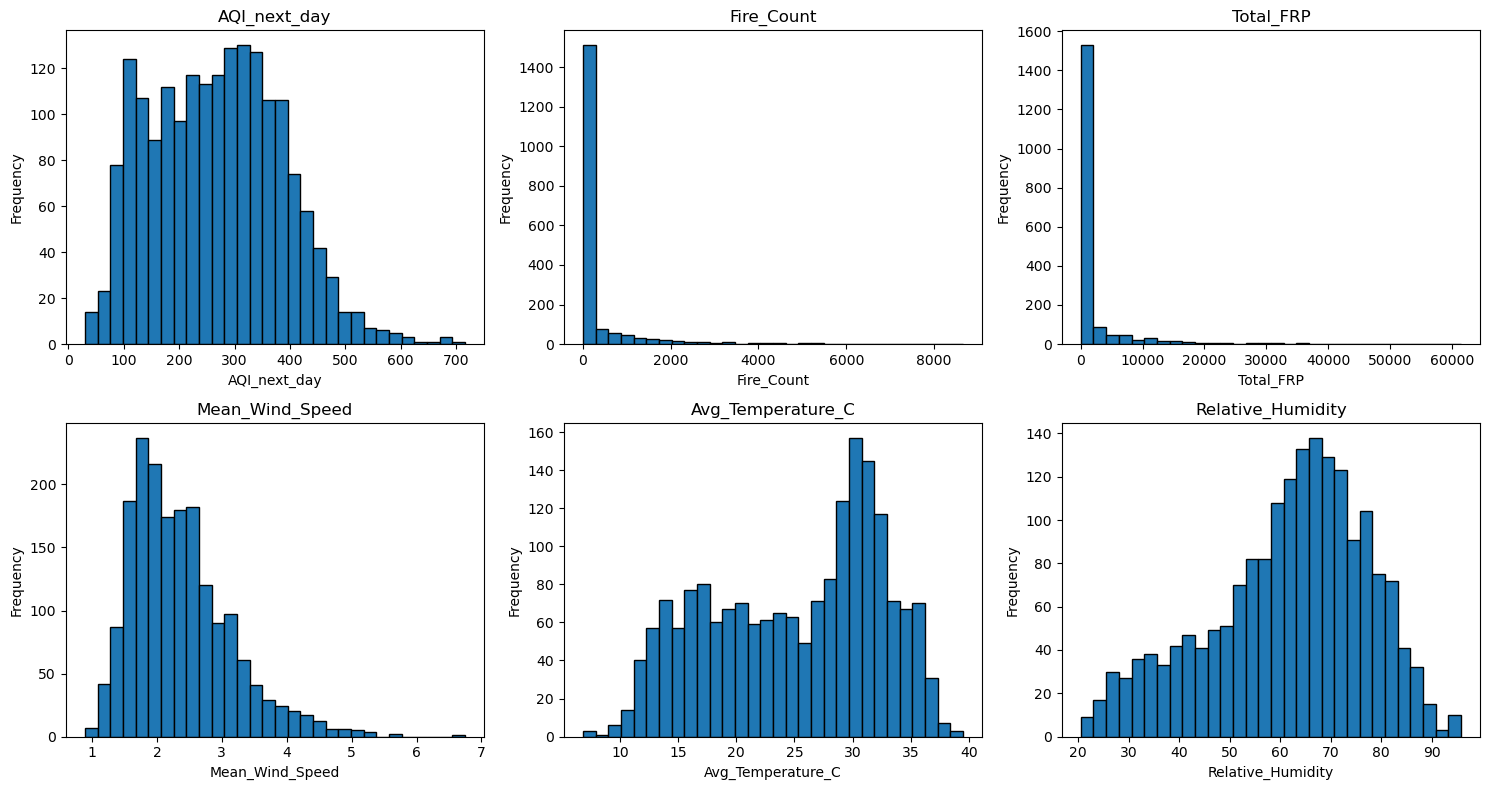

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes = axes.flatten()

for ax, column in zip(axes, key_variables):

    ax.hist(
        feature_df[column],
        bins=30,
        edgecolor="black"
    )

    ax.set_title(column)
    ax.set_xlabel(column)
    ax.set_ylabel("Frequency")

plt.tight_layout()

plt.show()

## 3.2 Quantile-Quantile (Q-Q) Plots

Q-Q plots compare the observed distribution of each variable with the theoretical normal distribution. Variables whose observations closely follow the reference line can be considered approximately normally distributed, whereas systematic deviations indicate departures from normality.

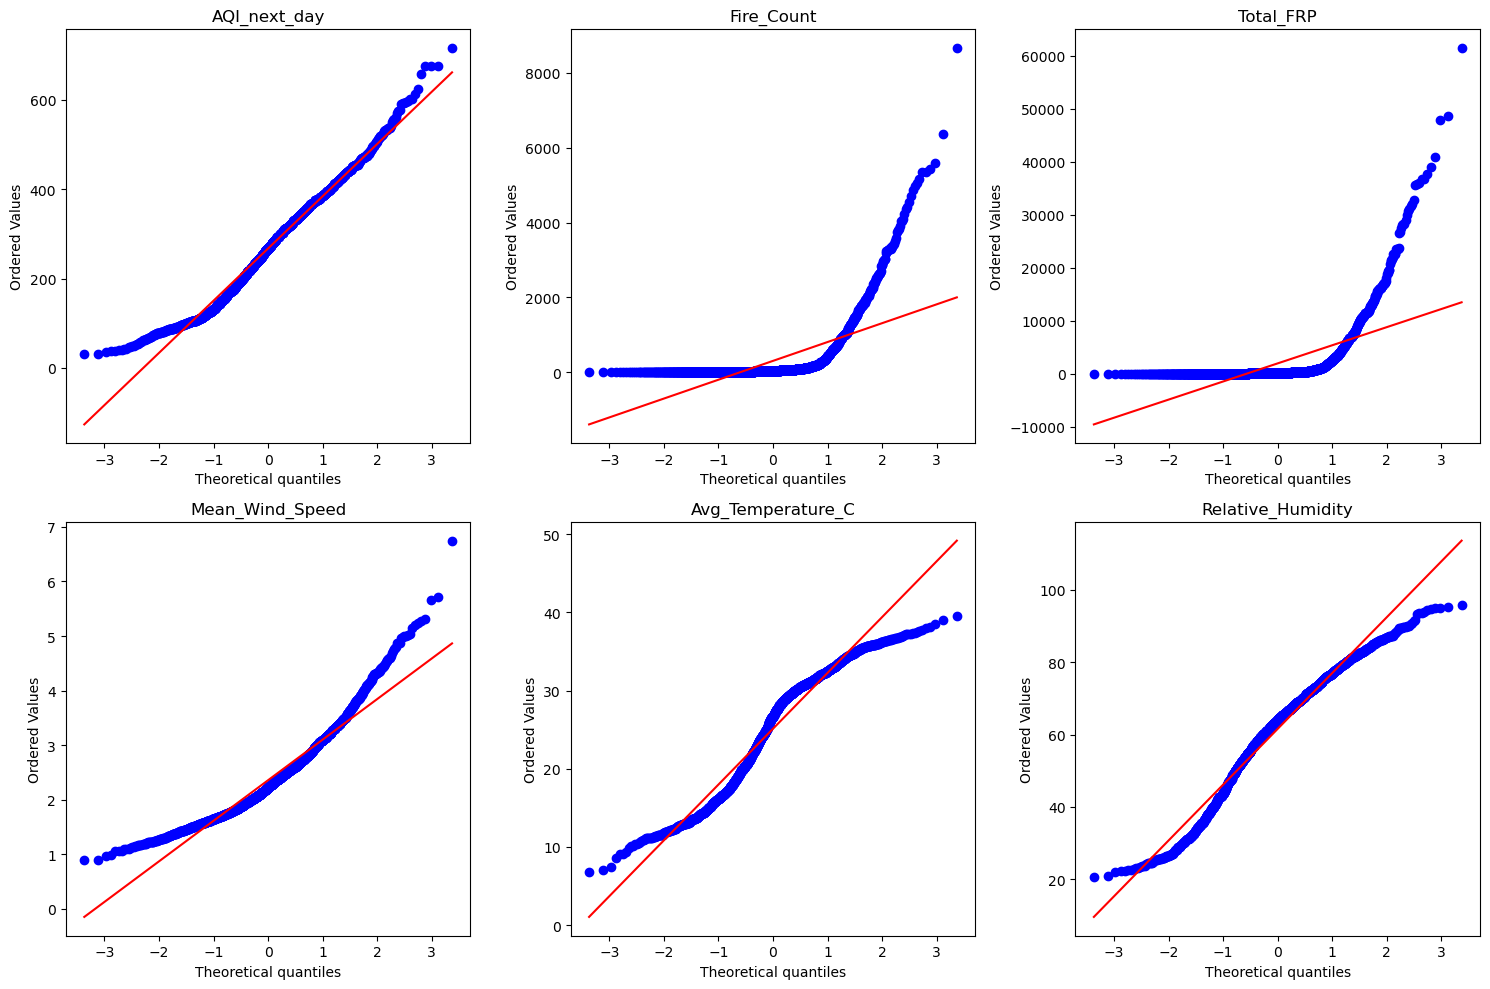

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes = axes.flatten()

for ax, column in zip(axes, key_variables):

    stats.probplot(
        feature_df[column],
        dist="norm",
        plot=ax
    )

    ax.set_title(column)

plt.tight_layout()

plt.show()

### Findings

The visual assessment indicates that the study variables exhibit varying distributional characteristics. AQI_next_day, Mean Wind Speed, Average Temperature, and Relative Humidity display distributions that are approximately symmetric, although minor deviations from normality are observed in the tails.

In contrast, Fire Count and Total Fire Radiative Power (FRP) exhibit pronounced positive skewness, with the majority of observations concentrated at lower values and a small number of extreme biomass burning events extending the upper tails of the distributions. The corresponding Q-Q plots further confirm substantial departures from the theoretical normal distribution for these fire-related variables.

The observed non-normality is consistent with the episodic nature of biomass burning, where relatively few days experience exceptionally intense fire activity. Such extreme observations represent genuine environmental events rather than measurement errors and are therefore retained for subsequent analysis.

Overall, the normality assessment indicates that while several meteorological variables approximate normal distributions, the fire-related variables display substantial right-skewness. These findings are considered during the interpretation of subsequent statistical analyses and model development.

## 3.2 Shapiro-Wilk Normality Test

Following the visual assessment, the Shapiro-Wilk test is performed to statistically evaluate whether the selected variables follow a normal distribution.

The hypotheses are defined as follows:

- **H₀:** The variable follows a normal distribution.
- **H₁:** The variable does not follow a normal distribution.

A significance level (α) of **0.05** is adopted. Variables with p-values less than 0.05 are considered to deviate significantly from a normal distribution.

Because the Shapiro-Wilk test is highly sensitive for moderately large datasets, its results are interpreted alongside the histogram and Q-Q plot rather than in isolation.

In [10]:
normality_results = []

for column in key_variables:

    statistic, p_value = stats.shapiro(feature_df[column])

    normality_results.append({
        "Variable": column,
        "Shapiro Statistic": statistic,
        "p-value": p_value
    })

normality_results = pd.DataFrame(normality_results)

normality_results

,Variable,Shapiro Statistic,p-value
0,AQI_next_day,0.982141,2.016986e-14
1,Fire_Count,0.439454,4.845370e-60
2,Total_FRP,0.408529,5.169690e-61
3,Mean_Wind_Speed,0.935160,1.236496e-27
4,Avg_Temperature_C,0.948209,5.313415e-25
5,Relative_Humidity,0.970542,5.266838e-19


In [11]:
normality_results["Interpretation"] = np.where(
    normality_results["p-value"] < 0.05,
    "Not Normally Distributed",
    "Approximately Normal"
)

normality_results

,Variable,Shapiro Statistic,p-value,Interpretation
0,AQI_next_day,0.982141,2.016986e-14,Not Normally Distributed
1,Fire_Count,0.439454,4.845370e-60,Not Normally Distributed
2,Total_FRP,0.408529,5.169690e-61,Not Normally Distributed
3,Mean_Wind_Speed,0.935160,1.236496e-27,Not Normally Distributed
4,Avg_Temperature_C,0.948209,5.313415e-25,Not Normally Distributed
5,Relative_Humidity,0.970542,5.266838e-19,Not Normally Distributed


### Findings

The Shapiro-Wilk test indicates that all selected variables have p-values below the significance level of 0.05, leading to the rejection of the null hypothesis of normality for each variable.

Among the variables examined, Fire Count and Total Fire Radiative Power (FRP) exhibit the lowest Shapiro-Wilk statistics, indicating the greatest departure from a normal distribution. These findings are consistent with the histogram and Q-Q plot analyses, which showed substantial positive skewness caused by a relatively small number of extreme biomass burning events.

Although AQI_next_day, Mean Wind Speed, Average Temperature, and Relative Humidity also produced statistically significant results, their histogram and Q-Q plot assessments suggest that these variables are considerably closer to a normal distribution than the fire-related variables. The statistically significant p-values are primarily attributable to the relatively large sample size, which increases the sensitivity of the Shapiro-Wilk test to even minor deviations from perfect normality.

Consequently, the Shapiro-Wilk results are interpreted alongside the visual assessments rather than in isolation, providing a more balanced evaluation of the distributional characteristics of the study variables.

### Normality Assessment Summary

The combined visual and statistical assessment indicates that the variables do not perfectly follow a normal distribution. Fire Count and Total Fire Radiative Power (FRP) exhibit pronounced positive skewness, reflecting the episodic occurrence of large biomass burning events. In contrast, AQI_next_day and the meteorological variables display distributions that are substantially closer to normality, with only moderate departures observed in the distribution tails.

The observed non-normality is consistent with the characteristics of environmental data and does not indicate data quality issues. Since the extreme fire observations represent genuine environmental events rather than measurement errors, they are retained in the dataset to preserve the integrity of the analysis.

Overall, the normality assessment confirms that the fire-related variables are the primary source of distributional skewness, while the remaining variables exhibit relatively stable distributions. These characteristics are considered during the interpretation of the subsequent statistical analyses and machine learning models.

# 4. Correlation Significance Analysis

The exploratory data analysis identified several linear relationships between air quality, biomass burning, and meteorological variables. However, correlation coefficients alone do not indicate whether these relationships are statistically significant.

This section performs Pearson correlation significance tests to determine whether the observed relationships are unlikely to have occurred by chance. The results provide statistical evidence supporting the relationships identified during exploratory data analysis and help identify variables that are most strongly associated with next-day AQI.

In [12]:
correlation_variables = [

    "AQI_next_day",

    "AQI_lag1",

    "Fire_Count",
    "Total_FRP",

    "Mean_Wind_Speed",

    "Avg_Temperature_C",

    "Relative_Humidity"

]

In [13]:
from scipy.stats import pearsonr

results = []

target = "AQI_next_day"

for column in correlation_variables:

    if column != target:

        r, p = pearsonr(

            feature_df[column],
            feature_df[target]

        )

        results.append({

            "Variable": column,
            "Correlation": r,
            "p-value": p

        })

correlation_results = pd.DataFrame(results)

correlation_results

,Variable,Correlation,p-value
0,AQI_lag1,0.795596,0.000000e+00
1,Fire_Count,0.346722,2.594018e-53
2,Total_FRP,0.333349,3.557933e-49
3,Mean_Wind_Speed,-0.217482,3.270603e-21
4,Avg_Temperature_C,-0.445449,1.017585e-90
5,Relative_Humidity,-0.112975,1.129596e-06


In [14]:
correlation_results["Significance"] = np.where(

    correlation_results["p-value"] < 0.05,

    "Significant",

    "Not Significant"

)

correlation_results

,Variable,Correlation,p-value,Significance
0,AQI_lag1,0.795596,0.000000e+00,Significant
1,Fire_Count,0.346722,2.594018e-53,Significant
2,Total_FRP,0.333349,3.557933e-49,Significant
3,Mean_Wind_Speed,-0.217482,3.270603e-21,Significant
4,Avg_Temperature_C,-0.445449,1.017585e-90,Significant
5,Relative_Humidity,-0.112975,1.129596e-06,Significant


### Findings

The Pearson correlation significance analysis confirms that all selected variables exhibit statistically significant relationships with next-day AQI (p < 0.05). Therefore, the null hypothesis that no linear relationship exists between each predictor and AQI_next_day is rejected for all variables.

Among the predictors, AQI_lag1 demonstrates the strongest positive correlation with AQI_next_day (r = 0.796), indicating that historical air quality is the most influential predictor of next-day pollution levels. This finding confirms the strong temporal persistence of air quality observed during the exploratory data analysis.

The fire-related variables also exhibit statistically significant positive correlations with AQI_next_day. Fire Count (r = 0.347) and Total Fire Radiative Power (FRP) (r = 0.333) indicate that increased regional biomass burning is associated with poorer air quality. However, the moderate magnitude of these correlations suggests that biomass burning contributes to AQI but is not the sole determinant of pollution levels.

Among the meteorological variables, Average Temperature shows the strongest negative correlation with AQI_next_day (r = -0.445), indicating that lower temperatures are generally associated with higher pollution levels. Mean Wind Speed (r = -0.217) and Relative Humidity (r = -0.113) also exhibit statistically significant negative relationships, although their associations with AQI are comparatively weaker.

Overall, the correlation significance analysis supports the findings of the exploratory data analysis by demonstrating that historical AQI, biomass burning, and meteorological conditions all contribute significantly to variations in next-day air quality. Nevertheless, the moderate correlations observed for the fire-related variables indicate that accurate AQI prediction requires the combined consideration of historical pollution levels, fire activity, and weather conditions.

### Correlation Significance Summary

The correlation significance analysis demonstrates that all selected predictor variables are significantly associated with next-day AQI. Historical AQI exhibits the strongest relationship, highlighting the importance of temporal persistence in air quality prediction. Biomass burning variables contribute positively to AQI, while meteorological variables exhibit generally negative relationships, particularly temperature.

These findings provide statistical support for the study hypothesis that next-day AQI is influenced by the combined effects of historical pollution, regional biomass burning, and meteorological conditions. Consequently, these variables are retained for the subsequent multiple linear regression analysis to evaluate their relative contributions when considered simultaneously.

# 5. Multiple Linear Regression

Correlation analysis evaluates the relationship between two variables independently. However, air quality is influenced by multiple environmental factors acting simultaneously.

Multiple Linear Regression is employed to quantify the independent contribution of historical AQI, biomass burning, and meteorological variables to next-day AQI while controlling for the influence of the remaining predictors.

The regression analysis provides estimates of regression coefficients, statistical significance, and overall model performance, thereby enabling the relative importance of each predictor to be evaluated.

In [15]:
import statsmodels.api as sm

In [16]:
X = feature_df[
    [
        "AQI_lag1",
        "Fire_Count",
        "Total_FRP",
        "Mean_Wind_Speed",
        "Avg_Temperature_C",
        "Relative_Humidity"
    ]
]

y = feature_df["AQI_next_day"]

In [17]:
X = sm.add_constant(X)

In [18]:
model = sm.OLS(y, X).fit()

In [19]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           AQI_next_day   R-squared:                       0.706
Model:                            OLS   Adj. R-squared:                  0.705
Method:                 Least Squares   F-statistic:                     737.9
Date:                Mon, 03 Aug 2026   Prob (F-statistic):               0.00
Time:                        14:22:30   Log-Likelihood:                -10297.
No. Observations:                1847   AIC:                         2.061e+04
Df Residuals:                    1840   BIC:                         2.065e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               369.1308     17.04

### Findings

The multiple linear regression model is statistically significant (F = 737.90, p < 0.001), indicating that the selected predictor variables collectively explain a significant proportion of the variation in next-day AQI.

The model achieved an R² value of 0.706, indicating that approximately 70.6% of the variation in AQI_next_day is explained by the combined effects of historical AQI, biomass burning, and meteorological variables. This demonstrates that the selected predictors provide substantial explanatory power for next-day air quality.

Among all predictors, AQI_lag1 exhibits the largest positive regression coefficient (β = 0.622, p < 0.001), confirming that historical air quality is the strongest predictor of next-day AQI. This finding is consistent with the strong temporal persistence observed throughout the exploratory data analysis.

Fire Count remains a statistically significant positive predictor (β = 0.039, p = 0.002), indicating that increased regional fire activity contributes to higher AQI values even after controlling for historical pollution and meteorological conditions.

Total Fire Radiative Power (FRP) also remains statistically significant (p = 0.048), although its regression coefficient is small and slightly negative. This suggests that, after accounting for Fire Count and the meteorological variables, FRP contributes limited additional independent information. The result may reflect shared information between Fire Count and FRP, which will be further examined using multicollinearity diagnostics.

Among the meteorological variables, Mean Wind Speed, Average Temperature, and Relative Humidity all exhibit statistically significant negative coefficients (p < 0.001). These findings indicate that stronger winds, higher temperatures, and increased humidity are generally associated with lower next-day AQI after accounting for the remaining predictors.

Overall, the regression analysis demonstrates that next-day AQI is influenced by the combined effects of historical air quality, biomass burning, and meteorological conditions, thereby supporting the study objective of integrating these environmental factors for AQI prediction.

# 6. Multicollinearity Assessment

Multiple Linear Regression assumes that the predictor variables are not excessively correlated with one another. When strong relationships exist among predictors, the estimated regression coefficients may become unstable, making it difficult to interpret the independent contribution of each variable.

This section evaluates multicollinearity using the Variance Inflation Factor (VIF). The analysis identifies predictors that contain overlapping information and assesses whether multicollinearity is likely to affect the interpretation of the regression model.

## 6.1 Variance Inflation Factor (VIF)

The Variance Inflation Factor (VIF) is used to quantify the degree of multicollinearity among the predictor variables included in the multiple linear regression model. High multicollinearity indicates that one or more predictors contain overlapping information, which can inflate the variance of regression coefficients and reduce the reliability of their individual interpretation.

The commonly accepted interpretation of VIF values is:

- **VIF < 5** : Low multicollinearity
- **5 ≤ VIF < 10** : Moderate multicollinearity
- **VIF ≥ 10** : High multicollinearity requiring further investigation

The VIF analysis is performed after the regression model to determine whether the observed regression coefficients are affected by multicollinearity among the predictor variables.

In [20]:
# Predictor variables used in the regression model

X = feature_df[
    [
        "AQI_lag1",
        "Fire_Count",
        "Total_FRP",
        "Mean_Wind_Speed",
        "Avg_Temperature_C",
        "Relative_Humidity"
    ]
]

In [21]:
# Add intercept

X_vif = sm.add_constant(X)

In [22]:
vif = pd.DataFrame()

vif["Variable"] = X_vif.columns

vif["VIF"] = [

    variance_inflation_factor(
        X_vif.values,
        i
    )

    for i in range(X_vif.shape[1])

]

vif

,Variable,VIF
0,const,131.218971
1,AQI_lag1,1.689391
2,Fire_Count,41.391288
3,Total_FRP,40.949037
4,Mean_Wind_Speed,1.109622
5,Avg_Temperature_C,1.996775
6,Relative_Humidity,1.659987


In [23]:
def interpret_vif(value):

    if value < 5:
        return "Low"

    elif value < 10:
        return "Moderate"

    else:
        return "High"


vif["Interpretation"] = vif["VIF"].apply(interpret_vif)

vif

,Variable,VIF,Interpretation
0,const,131.218971,High
1,AQI_lag1,1.689391,Low
2,Fire_Count,41.391288,High
3,Total_FRP,40.949037,High
4,Mean_Wind_Speed,1.109622,Low
5,Avg_Temperature_C,1.996775,Low
6,Relative_Humidity,1.659987,Low


### Findings

The Variance Inflation Factor (VIF) analysis indicates that most predictor variables exhibit low multicollinearity. AQI_lag1, Mean Wind Speed, Average Temperature, and Relative Humidity all have VIF values below 5, indicating that these variables provide largely independent information to the regression model.

In contrast, Fire Count (VIF = 41.39) and Total Fire Radiative Power (FRP) (VIF = 40.95) exhibit extremely high VIF values, indicating substantial multicollinearity between the two fire-related variables. This finding is consistent with the exploratory data analysis, which demonstrated an almost perfect positive correlation between Fire Count and Total FRP.

The high multicollinearity indicates that Fire Count and FRP capture highly overlapping information regarding regional biomass burning. Consequently, while both variables are individually associated with AQI, their regression coefficients become less stable when included simultaneously in the multiple linear regression model. This explains the small negative regression coefficient observed for FRP despite its positive correlation with AQI.

Overall, the VIF analysis confirms that multicollinearity is primarily confined to the fire-related variables, whereas the remaining predictors provide independent and reliable information for explaining variations in next-day AQI.

### Multicollinearity Summary

The multicollinearity assessment demonstrates that the regression model is not substantially affected by collinearity among the historical AQI and meteorological variables. However, the two fire-related variables exhibit considerable overlap because both describe different aspects of the same underlying environmental phenomenon.

Rather than indicating an error in the data, the observed multicollinearity reflects the inherent relationship between the frequency and intensity of biomass burning events. Since the primary objective of this notebook is statistical interpretation, the multicollinearity is documented and considered during the interpretation of the regression coefficients.

The machine learning models developed in the subsequent notebook are expected to be less sensitive to multicollinearity, particularly the tree-based algorithms, which can effectively utilise correlated predictor variables without requiring their removal.

# 7. Statistical Analysis Summary

This notebook statistically validated the relationships identified during the exploratory data analysis and evaluated the engineered features prior to machine learning model development.

The major findings are summarised as follows:

- Descriptive statistics confirmed substantial variability in AQI and biomass burning activity throughout the study period.
- The normality assessment indicated that fire-related variables exhibit pronounced positive skewness, while the remaining variables display distributions closer to normality.
- Pearson correlation significance analysis demonstrated that historical AQI, biomass burning, and meteorological variables are all significantly associated with next-day AQI.
- Multiple linear regression showed that historical AQI is the strongest predictor of next-day air quality, while biomass burning and meteorological variables provide additional statistically significant explanatory power.
- Variance Inflation Factor analysis revealed considerable multicollinearity between Fire Count and Total Fire Radiative Power, confirming that these variables capture overlapping information regarding biomass burning.

Overall, the statistical analysis supports the study hypothesis that next-day AQI is influenced by the combined effects of historical pollution, regional biomass burning, and meteorological conditions. These validated features provide a strong statistical foundation for the machine learning models developed in the subsequent notebook.